### Firn paper figures 

This notebook only contains the code needed to produce the three figures in my Cryosphere Brief Communications submission. 

Package conflicts require the need for two separate environments. 
- cfm_env is used for Figures 2 and 3 which open HDF5 files and plot the results from the CFM
- plot_env is used for Figure 1 which includes mapping libraries to put the Alaska map on panel e. 

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
from plotting_fxns import *
import pickle
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Firn/'
sites = ['EC','T','Z','KPS','KQU']
out_fp = base_fp + 'Output/'
site_colors = {'EC':'#fcc02e',
               'T':    "#E14E9A", 
    'Z':    "#8E41AF", 

    'KQU':"#28CD8E",'KPS':"#0077FF"
}

# 'KQU':"#23da38",'KPS':"#1e9397",'Z': "#6424fa",'T': "#d83dff"}

starting EC
starting T
starting Z
starting KPS
starting KQU


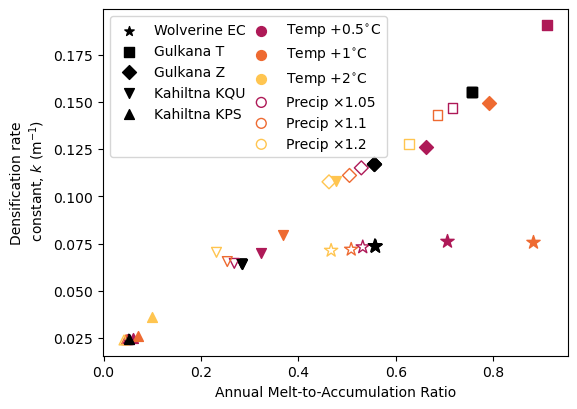

In [5]:
# FIGURE 3
redo_dict = True
if redo_dict:
    out_fn = out_fp + 'SITE/SITE_sitecal/CFMresults.hdf5'
    forcing_fn = base_fp + 'Forcings/SITE/SITE_1d_sitecal_forcings.csv'
    out_dict = get_dict(sites, out_fn, forcing_fn)
    # with open('site_dict.pkl','wb') as f:
    #     pickle.dump(out_dict, f)
else:
    with open('site_dict.pkl','rb') as f:
        out_dict = pickle.load(f)
sensitivity_figure('density_gradient','MELT_ACC_RATIO', out_dict)

In [ ]:
# PREPARATIONS FOR FIGURE 2

sites_compare = ['EC', 'T', 'Z', 'KPS']
depths = np.arange(0, 26, 0.05)
site_dates = {'EC': dates_wolverine_spring[-1], 'KPS': dates_KPS_spring[-1],
              'T': '2025_04_20', 'Z': '2025_04_20'}
by_site = {}
by_date = {}

for site in sites_compare:
    glacier = get_glacier(site)
    date = site_dates[site]
    density_meas, layer_tops, layer_bottoms = get_density_measured(site, date)

    # Load model output
    cfm_fn = base_fp + f'Output/{glacier}{site}/{glacier}{site}_tpx1/CFMresults.hdf5'
    output = h5py.File(cfm_fn, 'r')
    all_decimal_time = output['density'][:, 0]
    target_time = to_decimal_year(pd.to_datetime(date.replace('_', '/')))[0]
    index = np.where(np.abs(all_decimal_time - target_time) < 0.0005)[0]
    if len(index) == 0:
        index = len(all_decimal_time) - 1

    depth_mod = output['depth'][1:]
    density_mod = output['density'][index, 1:]
    if len(density_mod) == 1:
        density_mod = density_mod[0]

    # Crop measurement to exclude seasonal snow
    snow_df = pd.read_csv(f'../Data/cores/{glacier}/{glacier}{site}_snowdepth.csv')
    min_depth = snow_df.loc[snow_df['date'] == date, 'snowdepth'].values[0]
    valid = layer_tops >= min_depth
    layer_middles = layer_bottoms[valid] + (layer_bottoms[valid] - layer_tops[valid]) / 2
    density_meas = density_meas[valid]
    max_depth = layer_bottoms[valid][-1]

    # Interpolate to uniform depth grid
    by_site[site] = {
        'density_meas': np.interp(depths, layer_middles, density_meas),
        'density_mod': np.interp(depths, depth_mod, density_mod),
        'min_depth': min_depth,
        'max_depth': max_depth
    }

    # Mask outside valid range
    for key in ['density_meas', 'density_mod']:
        by_site[site][key][depths < min_depth] = np.nan
        by_site[site][key][depths > max_depth] = np.nan

for date in dates_wolverine_spring:
    glacier = 'wolverine'
    site = 'EC'
    density_meas, layer_tops, layer_bottoms = get_density_measured(site, date)

    # Load model output
    cfm_fn = base_fp + f'Output/{glacier}{site}/{glacier}{site}_tpx1/CFMresults.hdf5'
    output = h5py.File(cfm_fn, 'r')
    all_decimal_time = output['density'][:, 0]
    target_time = to_decimal_year(pd.to_datetime(date.replace('_', '/')))[0]
    index = np.where(np.abs(all_decimal_time - target_time) < 0.0005)[0]
    if len(index) == 0:
        index = len(all_decimal_time) - 1

    depth_mod = output['depth'][1:]
    density_mod = output['density'][index, 1:]
    if len(density_mod) == 1:
        density_mod = density_mod[0]

    # Crop measurement to exclude seasonal snow
    snow_df = pd.read_csv(f'../Data/cores/{glacier}/{glacier}{site}_snowdepth.csv')
    min_depth = snow_df.loc[snow_df['date'] == date, 'snowdepth'].values[0]
    valid = layer_tops >= min_depth
    layer_middles = layer_bottoms[valid] + (layer_bottoms[valid] - layer_tops[valid]) / 2
    density_meas = density_meas[valid]
    max_depth = layer_bottoms[valid][-1]

    # Interpolate to uniform depth grid
    by_date[date] = {
        'density_meas': np.interp(depths, layer_middles, density_meas),
        'density_mod': np.interp(depths, depth_mod, density_mod),
        'min_depth': min_depth,
        'max_depth': max_depth
    }

    # Mask outside valid range
    for key in ['density_meas', 'density_mod']:
        by_date[date][key][depths < min_depth] = np.nan
        by_date[date][key][depths > max_depth] = np.nan

# Compute leave-one-out deviations
sitewise_obs = {site: [] for site in sites_compare}
sitewise_mod = {site: [] for site in sites_compare}
yearwise_obs = {date: [] for date in dates_wolverine_spring}
yearwise_mod = {date: [] for date in dates_wolverine_spring}

# Compute depth bounds separately for sitewise and yearwise comparisons
min_depth_site = np.sort([by_site[s]['min_depth'] for s in sites_compare])[1]
max_depth_site = np.sort([by_site[s]['max_depth'] for s in sites_compare])[-2]
bin_edges_site = np.arange(min_depth_site, max_depth_site + 0.5, 0.5)

min_depth_year = np.sort([by_date[d]['min_depth'] for d in dates_wolverine_spring])[1]
max_depth_year = np.sort([by_date[d]['max_depth'] for d in dates_wolverine_spring])[-2]
bin_edges_year = np.arange(min_depth_year, max_depth_year + 0.5, 0.5)

# --- Sitewise deviations ---
for b_start, b_end in zip(bin_edges_site[:-1], bin_edges_site[1:]):
    in_bin = (depths >= b_start) & (depths < b_end)

    obs_vals = {s: np.nanmean(by_site[s]['density_meas'][in_bin])
                for s in sites_compare if np.any(~np.isnan(by_site[s]['density_meas'][in_bin]))}
    mod_vals = {s: np.nanmean(by_site[s]['density_mod'][in_bin])
                for s in sites_compare if np.any(~np.isnan(by_site[s]['density_mod'][in_bin]))}

    overlapping_sites = list(set(obs_vals) & set(mod_vals))
    if len(overlapping_sites) >= 2:
        for site in overlapping_sites:
            others_obs = [v for s, v in obs_vals.items() if s != site]
            others_mod = [v for s, v in mod_vals.items() if s != site]
            for obs in others_obs:
                if not np.isnan(obs):
                    sitewise_obs[site].append(obs_vals[site] - obs)
            for mod in others_mod:
                if not np.isnan(mod):
                    sitewise_mod[site].append(mod_vals[site] - mod)
            # sitewise_obs[site].append((obs_vals[site] - np.nanmean(others_obs)) * (len(overlapping_sites) - 1))
            # sitewise_mod[site].append((mod_vals[site] - np.nanmean(others_mod)) * (len(overlapping_sites) - 1))

# --- Yearwise deviations at EC ---
for b_start, b_end in zip(bin_edges_year[:-1], bin_edges_year[1:]):
    in_bin = (depths >= b_start) & (depths < b_end)

    obs_vals = {d: np.nanmean(by_date[d]['density_meas'][in_bin])
                for d in dates_wolverine_spring if np.any(~np.isnan(by_date[d]['density_meas'][in_bin]))}
    mod_vals = {d: np.nanmean(by_date[d]['density_mod'][in_bin])
                for d in dates_wolverine_spring if np.any(~np.isnan(by_date[d]['density_mod'][in_bin]))}

    overlapping_dates = list(set(obs_vals) & set(mod_vals))
    if len(overlapping_dates) >= 2:
        for date in overlapping_dates:
            others_obs = [v for d, v in obs_vals.items() if d != date]
            others_mod = [v for d, v in mod_vals.items() if d != date]
            for obs in others_obs:
                if not np.isnan(obs):
                    yearwise_obs[date].append(obs_vals[date] - obs)
            for mod in others_mod:
                if not np.isnan(mod):
                    yearwise_mod[date].append(mod_vals[date] - mod)

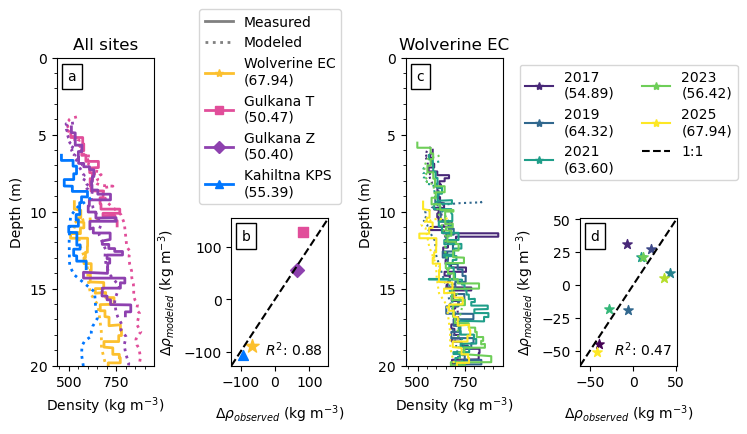

In [9]:
# FIGURE 2
all_measured = []
all_modeled = []
string = 'tpx1'
sites_compare = ['EC','T','Z','KPS']

# GRIDSPEC
fig = plt.figure(figsize=(8, 4))
gs = mpl.gridspec.GridSpec(2, 4, figure=fig, wspace=0.8, hspace=0.51, height_ratios=[1, 1.5]) #, width_ratios=[1,1.5,1,1.5])

# Spatial plots
ax1 = fig.add_subplot(gs[0:3, 0])
lax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 1])

# Temporal plots
ax4 = fig.add_subplot(gs[0:3, 2], sharex=ax1, sharey=ax1)
lax2 = fig.add_subplot(gs[0, 3])
ax5 = fig.add_subplot(gs[1, 3])

lax1.plot(np.nan, np.nan, c='gray', linewidth=2, label='Measured')
lax1.plot(np.nan, np.nan, c='gray', linewidth=2, linestyle=':', label='Modeled')

# SPATIAL
for si, site in enumerate(sites_compare):
    # measured
    glacier = get_glacier(site)
    if site == 'EC':
        date = dates_wolverine[-1]
    elif site == 'KPS':
        date = dates_KPS[-1]
    elif site == 'KQU':
        date = dates_KQU[-1] 
    else:
        date = '2025_04_20'
    density_meas, layer_tops, layer_bottoms = get_density_measured(site, date)

    # modeled
    cfm_fn = base_fp + f'Output/{glacier}{site}/{glacier}{site}_{string}/CFMresults.hdf5'
    output = h5py.File(cfm_fn,'r')

    # plot depth vs density
    all_decimal_time = output['density'][:, 0]
    date_fmtd = '2025-04-20' if date == '2025' else date.replace('_','/')
    target_time = to_decimal_year(pd.to_datetime(date_fmtd))[0]
    index = np.where(np.abs(all_decimal_time - target_time) < 0.0005)[0]
    if len(index) == 0:
        index = len(output['density'][:, 0]) - 1

    # get depth and data arrays
    depth_mod = output['depth'][1:]
    density_mod = output['density'][index, 1:]
    age_mod = output['age'][index, 1:]
    if len(density_mod) == 1:
        density_mod = density_mod[0]
        age_mod = age_mod[0]

    # get depth of seasonal snow
    snow_df = pd.read_csv(f'../Data/cores/{glacier}/{glacier}{site}_snowdepth.csv')
    min_depth = snow_df.loc[snow_df['date'] == date, 'snowdepth'].values
    density_meas = density_meas[layer_tops >= min_depth]
    layer_bottoms = layer_bottoms[layer_tops >= min_depth]
    layer_tops = layer_tops[layer_tops >= min_depth]
    layer_middles = layer_bottoms + (layer_bottoms - layer_tops) / 2

    # GET R2
    y_pred = np.interp(layer_middles, depth_mod, density_mod)
    y_true = density_meas
    RMSE = np.sqrt(np.mean(np.square(y_pred - y_true)))
    # ax1.text(0.5, 0.95 - si/15, f'{RMSE:.2f}', 
    #          transform=ax1.transAxes,fontweight='bold',
    #          fontdict={'color':site_colors[site]})

    density_mod = density_mod[age_mod >= 1]
    depth_mod = depth_mod[age_mod >= 1]
                                 
    density_plot = []
    depth_plot = []
    for density_meas_layer, top, bottom in zip(density_meas, layer_tops, layer_bottoms):
        layer_idx = np.where((depth_mod >= top) & (depth_mod <= bottom))[0]
        if len(layer_idx) > 0:
            density_mod_layer = np.mean(density_mod[layer_idx])
        else:
            density_mod_layer = np.nan
        depth_plot.append([top, bottom])
        density_plot.append([density_meas_layer, density_meas_layer])
    ax1.plot(np.array(density_plot).flatten(), np.array(depth_plot).flatten(), color=site_colors[site], 
             linewidth=2, label=get_glacier(site).capitalize()+' '+site)
    lax1.plot(np.nan, np.nan,color=site_colors[site], marker=markers[site], 
             linewidth=2, label=get_glacier(site).capitalize()+' '+site+f'\n({RMSE:.2f})')

    # plot modeled density
    ax1.plot(density_mod, depth_mod, color=site_colors[site], linestyle=':', linewidth=2)

# beautify
lax1.legend(loc='center', bbox_to_anchor=(0.4,0.5))
lax1.axis('off')
ax1.invert_yaxis()
ax1.set_yticks([0,5,10,15,20])
ax1.set_ylim(20, 0)
ax1.minorticks_on()

# TEMPORAL
site = 'EC'
glacier = get_glacier(site)
    
cmap = plt.colormaps.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=0, vmax=len(dates_wolverine_spring)-1)
for d, date in enumerate(dates_wolverine_spring):
    if date in np.array(dates_wolverine_spring)[::2]:
        # lax2.plot(np.nan, np.nan, color=cmap(norm(d)), marker='*', label=date[:4])
        continue
    density_meas, layer_tops, layer_bottoms = get_density_measured(site, date)
    layer_middles = layer_bottoms + (layer_bottoms - layer_tops) / 2

    # modeled
    cfm_fn = base_fp + f'Output/{glacier}{site}/{glacier}{site}_{string}/CFMresults.hdf5'
    output = h5py.File(cfm_fn,'r')

    # plot depth vs density
    all_decimal_time = output['density'][:, 0]
    date_fmtd = '2025-04-20' if date == '2025' else date.replace('_','/')
    target_time = to_decimal_year(pd.to_datetime(date_fmtd))[0]
    index = np.where(np.abs(all_decimal_time - target_time) < 0.0005)[0]
    if len(index) == 0:
        index = len(output['density'][:, 0]) - 1

    # get depth and data arrays
    depth_mod = output['depth'][1:]
    density_mod = output['density'][index, 1:]
    age_mod = output['age'][index, 1:]
    if len(density_mod) == 1:
        density_mod = density_mod[0]
        age_mod = age_mod[0]

    # get depth of seasonal snow
    snow_df = pd.read_csv(f'../Data/cores/{glacier}/{glacier}{site}_snowdepth.csv')
    min_depth = snow_df.loc[snow_df['date'] == date, 'snowdepth'].values
    density_meas = density_meas[layer_tops >= min_depth]
    layer_bottoms = layer_bottoms[layer_tops >= min_depth]
    layer_tops = layer_tops[layer_tops >= min_depth]
    layer_middles = layer_bottoms + (layer_bottoms - layer_tops) / 2

    # GET R2
    y_pred = np.interp(layer_middles, depth_mod, density_mod)
    y_true = density_meas
    RMSE = np.sqrt(np.mean(np.square(y_pred - y_true)))
    # ax4.text(0.5, 0.985 - d/32, f'{RMSE:.2f}', 
    #          transform=ax4.transAxes,fontweight='bold',
    #          fontdict={'color':cmap(norm(d))})
    
    density_mod = density_mod[age_mod >= 1]
    depth_mod = depth_mod[age_mod >= 1]

    density_plot = []
    depth_plot = []
    for density_meas_layer, top, bottom in zip(density_meas, layer_tops, layer_bottoms):
        layer_idx = np.where((depth_mod >= top) & (depth_mod <= bottom))[0]
        if len(layer_idx) > 0:
            density_mod_layer = np.mean(density_mod[layer_idx])
        else:
            density_mod_layer = np.nan
        depth_plot.append([top, bottom])
        density_plot.append([density_meas_layer, density_meas_layer])
    ax4.plot(np.array(density_plot).flatten(), np.array(depth_plot).flatten(), color=cmap(norm(d)))
    ax4.plot(density_mod, depth_mod, color=cmap(norm(d)), linestyle=':')
    # diff = np.interp(layer_middles, depth_mod, density_mod) - density_meas
    # ax4.plot(diff, layer_middles, color=cmap(norm(d)),label=date[:4])
    lax2.plot(np.nan, np.nan, color=cmap(norm(d)), marker='*', label=date[:4]+f'\n({RMSE:.2f})')

# beautify
lax2.plot(np.nan, np.nan, 'k--', label='1:1')
lax2.legend(ncols=2, loc='upper center')
lax2.axis('off')
ax4.set_title('Wolverine EC')
# ax1.minorticks_on()
# ax1.set_title(r'ln($\rho$/$\rho_{ice} - \rho$)')
for ax in [ax2, ax5]:
    ax.set_xlabel(r'$k_{measured}$')
    ax.set_ylabel(r'$k_{modeled}$')
    ax.xaxis.set_label_coords(0.5, -0.25)

for letter, ax in zip(['a','b','c','d'], [ax1,ax2, ax4,ax5]):
    y = 0.88 if letter in ['b','d'] else 0.94
    ax.text(0.152, y, letter, fontsize=10, ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='black'), transform=ax.transAxes)

# Plot the scatter BY SITE
all_mod = []
all_obs = []
for site in sites_compare:
    size = 100 if markers[site] == '*' else 50
    ax2.scatter(np.mean(sitewise_obs[site]), np.mean(sitewise_mod[site]), s=size, 
            color=site_colors[site], marker=markers[site], label=get_glacier(site).capitalize()+' '+site)
    all_mod.append(np.mean(sitewise_mod[site]))
    all_obs.append(np.mean(sitewise_obs[site]))
ss_res = np.sum((np.array(all_obs) - np.array(all_mod)) ** 2)
ss_tot = np.sum((np.array(all_obs) - np.mean(np.array(all_obs))) ** 2)
R2 = 1 - ss_res / ss_tot
min_all = np.min([all_obs, all_mod])
max_all = np.max([all_obs, all_mod])
ax2.plot([min_all * 1.2, max_all * 1.2],
        [min_all * 1.2, max_all * 1.2],
        'k--', label='1:1')
ax2.set_xlim(min_all*1.2, max_all*1.2)
ax2.set_ylim(min_all*1.2, max_all*1.2)
ax2.text(0.35, 0.07, f'$R^2$: {R2:.2f}', transform=ax2.transAxes, color='k')
ax2.set_xlabel(r'$\Delta \rho_{observed}$ (kg m$^{-3}$)')
ax2.set_ylabel(r'$\Delta \rho_{modeled}$ (kg m$^{-3}$)')

# Plot the scatter BY DATE
all_mod = []
all_obs = []
for d, date in enumerate(dates_wolverine_spring):
    size = 100 if markers[site] == '*' else 50
    ax5.scatter(np.mean(yearwise_obs[date]), np.mean(yearwise_mod[date]), s=size, 
            color=cmap(norm(d)), marker=markers['EC'], label=date[:4])
    all_mod.append(np.mean(yearwise_mod[date]))
    all_obs.append(np.mean(yearwise_obs[date]))
ss_res = np.sum((np.array(all_obs) - np.array(all_mod)) ** 2)
ss_tot = np.sum((np.array(all_obs) - np.mean(np.array(all_obs))) ** 2)
R2 = 1 - ss_res / ss_tot
ax5.text(0.35, 0.07, f'$R^2$: {R2:.2f}', transform=ax5.transAxes, color='k')
min_all = np.min([all_obs, all_mod])
max_all = np.max([all_obs, all_mod])

ax5.plot([min_all * 1.2, max_all * 1.2],
        [min_all * 1.2, max_all * 1.2],
        'k--', label='1:1')
ax5.set_xlim(min_all*1.2, max_all*1.2)
ax5.set_ylim(min_all*1.2, max_all*1.2)
ax5.set_xlabel(r'$\Delta \rho_{observed}$ (kg m$^{-3}$)')
ax5.set_ylabel(r'$\Delta \rho_{modeled}$ (kg m$^{-3}$)')

# for aaxx in [ax, ax1]:
#     aaxx.legend()
#     aaxx.invert_yaxis()
#     aaxx.set_ylim(20, 0)
ax1.set_xlabel('Density (kg m$^{-3}$)')
ax4.set_xlabel('Density (kg m$^{-3}$)')
ax1.set_title('All sites')
ax1.set_ylabel('Depth (m)')
ax4.set_ylabel('Depth (m)')
plt.tight_layout()
plt.savefig(base_fp + 'Figs/Figure2.png',dpi=300, bbox_inches='tight')
plt.show()

In [1]:
####### REQUIRES PLOT_ENV #######
#################################

%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
import pickle
import warnings
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
base_fp = '/trace/group/rounce/cvwilson/Firn/'
colors = ['#63c4c7','#fcc02e','#4D559C','#BF1F6A','#60C252',
              '#F77808','#298282','#999999','#FF89B0','#427801']
dates_wolverine = ['2016_05_13', '2016_06_02', '2016_07_12', '2016_08_16',
                   '2016_09_10', '2017_04_26', '2017_06_16', '2017_07_22', 
                   '2017_09_09', '2018_05_02', '2018_09_08', '2019_05_22', 
                   '2019_09_05', '2020_05_12', '2020_09_09', '2021_04_19', 
                   '2021_08_29', '2022_04_28', '2022_09_18', '2023_05_06', 
                   '2023_09_06', '2024_04_26', '2025_05_09']
dates_wolverine_spring = ['2016_05_13', '2017_04_26', '2018_05_02',
                            '2019_05_22', '2020_05_12', '2021_04_19', 
                            '2022_04_28', '2023_05_06','2024_04_26', 
                            '2025_05_09']
dates_KPS = ['2024_05_26', '2024_09_30', '2025_05_23']
dates_KPS_spring = ['2024_05_26','2025_05_23']
dates_KQU = ['2024_05_25', '2025_05_23']
site_elevation = {'Z':2081, 'T':1877, 'EC':1348, 'KQU':2630, 'KPS':3053, 'KT1':2690,'KT2':2846,'KT3':2900}

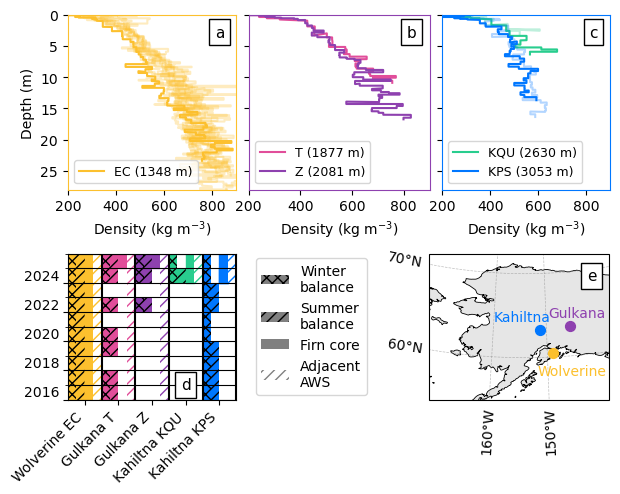

In [7]:
site_colors = {'EC':'#fcc02e',
               'T':    "#E14E9A", 
    'Z':    "#8E41AF", 

    'KQU':"#28CD8E",'KPS':"#0077FF"
}

# Load shapefiles
alaska = gpd.read_file(base_fp + 'tl_2024_02_place/tl_2024_02_place.shp')

# Coordinates to mark (lon, lat)
points = {'Gulkana':(63.288623,-145.482731),
          'Wolverine':(60.42594,-148.914234),
          'Kahiltna':(63.07663386,-151.1742604)}
glacier_colors = {'Gulkana':site_colors['Z'],
          'Wolverine':site_colors['EC'],
          'Kahiltna':site_colors['KPS']}
glacier_sites = {'Gulkana':{'T':site_colors['T'], 'Z':site_colors['Z']},
          'Wolverine':{'EC':site_colors['EC']},
          'Kahiltna':{'KQU':site_colors['KQU'],'KPS':site_colors['KPS']}}

point_gdf = gpd.GeoDataFrame(geometry=[Point(points[key][1], points[key][0]) for key in points], crs="EPSG:4326")

fig = plt.figure(figsize=(7, 5))
gs = mpl.gridspec.GridSpec(2, 4, figure=fig, width_ratios=[1,0.99,0.01,1], wspace=0.1, hspace=0.4, height_ratios=[1.2, 1])

# Regular plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1:3])
ax3 = fig.add_subplot(gs[0, 3])

# Info plots
ax4 = fig.add_subplot(gs[1, 0])
lax4 = fig.add_subplot(gs[1, 1])

# Map plot 
gax = fig.add_subplot(gs[1, 2:4], projection=ccrs.AlbersEqualArea(central_longitude=-154, central_latitude=60))

# Add features
# ax.add_feature(cfeature.BORDERS, linestyle=':')
gax.add_feature(cfeature.OCEAN, facecolor='1')
gax.add_feature(cfeature.LAND, facecolor='0.9')
gax.add_feature(cfeature.COASTLINE,linewidth=0.6)
gax.set_extent([-170, -140, 55, 72], crs=ccrs.Geodetic())
gl = gax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlocator = mpl.ticker.FixedLocator([-160, -150])  # Longitudes
gl.ylocator = mpl.ticker.FixedLocator([60, 70])

# Add points and labels next to each point
crs = ccrs.AlbersEqualArea(central_longitude=-154, central_latitude=60)
for name, geom in zip(points.keys(), point_gdf.geometry):
    x = -3.5 if name == 'Kahiltna' else 1.5 if name == 'Gulkana' else 3
    y = 1 if name == 'Kahiltna' else 1 if name == 'Gulkana' else -2.5
    gax.scatter(geom.x, geom.y, transform=ccrs.Geodetic(),
               color=glacier_colors[name], marker='o', s=50,zorder=10)
    gax.text(geom.x + x, geom.y + y, name,
            transform=ccrs.Geodetic(),
            fontsize=10, color=glacier_colors[name], ha='center')

axes = [ax2, ax1, ax3]
with open('site_data.pkl','rb') as f:
    data_dict = pickle.load(f)
site_years = {}
for ax, glacier in zip(axes, glacier_sites):
    USGS_fp = f'/trace/home/cvwilson/research/MB_data/{glacier}/Input_{glacier}_Glaciological_Data.csv'
    df_mb_glacier = pd.read_csv(USGS_fp, index_col='Year')
    
    for site in glacier_sites[glacier]:
        color = glacier_sites[glacier][site]
        data = data_dict[site]

        df_mb = df_mb_glacier.loc[df_mb_glacier['site_name'] == site]
        this_winter_abl_data = df_mb['winter_ablation'].values
        past_summer_acc_data = np.append(np.zeros(1), df_mb['summer_accumulation'].values[:-1])
        this_summer_acc_data = df_mb['summer_accumulation'].values
        past_summer_acc_data[np.isnan(past_summer_acc_data)] = 0
        this_summer_acc_data[np.isnan(this_summer_acc_data)] = 0
        this_winter_abl_data[np.isnan(this_winter_abl_data)] = 0
        # print(df_mb['bw'].values, past_summer_acc_data, this_winter_abl_data, this_summer_acc_data)
        winter_data = df_mb['bw'].values - past_summer_acc_data + this_winter_abl_data
        summer_data = df_mb['ba'].values - df_mb['bw'].values + this_summer_acc_data
        bw = f'+{np.nanmean(winter_data):.2f}'
        bs = f'{np.nanmean(summer_data):.2f}' if np.nanmean(summer_data) < 0 else f'+{np.nanmean(summer_data):.2f}'
        site_years[site] = {'winter_years':df_mb.index[np.where(~np.isnan(winter_data))[0]],
                            'summer_years':df_mb.index[np.where(~np.isnan(summer_data))[0]]
                            }
        
        for date, tops, bottoms, density in zip(data['dates'], data['layer_tops'], data['layer_bottoms'], data['density_meas']):
            depth_plot = []
            density_plot = []
            for density_meas_layer, top, bottom in zip(density, tops, bottoms):
                depth_plot.append([top, bottom])
                density_plot.append([density_meas_layer, density_meas_layer])
            alpha = 1 if date == data['dates'][-1] else 0.3
            linestyle = '-' if date == data['dates'][-1] else ':'
            weight = 2 if date == data['dates'][-1] else 1
            ax.plot(np.array(density_plot).flatten(), np.array(depth_plot).flatten(), color=color, alpha=alpha) #linewidth=weight, linestyle=linestyle)
            if date == data['dates'][0]:
                site_elev = site_elevation[site]
                ax.plot(np.nan, np.nan, color=color, label=site+f' ({site_elev} m)')
        
        for spine in ax.spines.values():
            spine.set_edgecolor(glacier_colors[glacier])
    ax.invert_yaxis()
    ax.set_ylim(28, 0)
    ax.set_xlim(200, 900)
    ax.legend(loc='lower left',fontsize=9)
for ax in [ax2, ax3]:
    ax.set_yticklabels([])

sites = ['EC','T','Z','KQU','KPS']
for si, site in enumerate(sites):
    glacier = 'Kahiltna' if 'K' in site else 'Wolverine' if site == 'EC' else 'Gulkana'
    USGS_fp = f'/trace/home/cvwilson/research/MB_data/{glacier}/Input_{glacier}_Glaciological_Data.csv'

    # Firn years
    dates_firn = {'Z':['2025_04_20'], 'T':['2025_04_20'], 'EC':dates_wolverine, 'KPS':dates_KPS, 'KQU':dates_KQU}
    years_firn = [int(date[:4]) for date in dates_firn[site]]

    # AWS years
    years_AWS = np.arange(2000, 2026) if glacier in ['Gulkana','Wolverine'] else np.arange(2024, 2026)
    
    # Load dataset
    df_mb = pd.read_csv(USGS_fp)
    df_mb = df_mb.loc[df_mb['site_name'] == site]
    df_mb.index = df_mb['Year']
    # years_summer = df_mb.loc[~np.isnan(df_mb['ba'])].index
    # years_winter = df_mb.loc[~np.isnan(df_mb['bw'])].index
    years_summer = site_years[site]['summer_years']
    years_winter = site_years[site]['winter_years']

    if site in ['EC','KPS']:
        years_winter = np.append(years_winter, 2025)
        if site == 'EC':
            years_summer = np.append(years_summer, 2025)
    xw = si
    xs = si + 1/4
    xf = si + 2/4
    xa = si + 3/4
    for year in years_winter:
        ax4.fill_between([xw-1/8,xw+1/8], year, year+1, color=site_colors[site], hatch='XXX',edgecolor='k', linewidth=0.)
    for year in years_summer:
        ax4.fill_between([xs-1/8,xs+1/8], year, year+1, color=site_colors[site], hatch='///',edgecolor='k', linewidth=0.)
    for year in years_firn:
        ax4.fill_between([xf-1/8,xf+1/8], year, year+1, color=site_colors[site])
    for year in years_AWS:
        ax4.fill_between([xa-1/8,xa+1/8], year, year+1, color='white', edgecolor=site_colors[site],hatch='///', linewidth=0)
    ax4.axvline(si+1-1/8, color='k')
    ax4.yaxis.minorticks_on()
    ax4.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(1))
    ax4.grid(axis='y',color='k')
    ax4.grid(axis='y', which='minor',color='k')
    ax4.set_yticks(np.arange(2016, 2026, 2))
    ax4.set_ylim(2016, 2026)
ax4.set_xticks(np.arange(0.5, 5.5)-1/8)
get_glacier = lambda site: 'gulkana' if site in ['Z','T'] else 'wolverine' if site == 'EC' else 'kahiltna'
ax4.set_xticklabels([get_glacier(site).capitalize()+' '+site for site in sites], rotation=45,ha='right' )
ax4.set_xlim(-1/8, 5-1/8)
ax4.set_yticklabels([])

# Manually place labels between major and minor ticks
for y in np.arange(2016, 2026, 2):
    ax4.text(-0.05, y + 0.5, str(y), va='center', ha='right', transform=ax4.get_yaxis_transform())

lax4.fill_between([0,1],np.nan, np.nan, color='gray',hatch='XXX',linewidth=0.,edgecolor='k',label='Winter\nbalance')
lax4.fill_between([0,1],np.nan, np.nan, color='gray',hatch='///',linewidth=0.,edgecolor='k',label='Summer\nbalance')
lax4.fill_between([0,1],np.nan, np.nan, color='gray',linewidth=0.,edgecolor='k',label='Firn core')
lax4.fill_between([0,1],np.nan, np.nan, color='white',hatch='///',linewidth=0.,edgecolor='gray',label='Adjacent\nAWS')
lax4.legend(loc='center left')
lax4.axis('off')

for letter, ax in zip(['a','b','c','e'], [ax1,ax2,ax3,gax]):
    x = 0.9
    y = 0.85 if letter == 'e' else 0.9
    ax.text(x, y, letter,transform=ax.transAxes,
        fontsize=11, ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='black'))
ax4.text(3.375, 2017, 'd',fontsize=11, ha='center', va='center',
        bbox=dict(facecolor='white', edgecolor='black'))

ax1.set_ylabel('Depth (m)')
for ax in [ax1,ax2,ax3]:
    ax.set_xlabel('Density (kg m$^{-3}$)')
plt.savefig(base_fp + 'Figs/Figure1.png',dpi=300, bbox_inches='tight')
plt.show()